# EXXA Image-Based Task — Protoplanetary Disk Reconstruction

Trains a convolutional autoencoder on DSHARP ALMA continuum images to reconstruct
protoplanetary disk morphology. Two loss functions are compared:

| Model | Loss |
|---|---|
| **MSE-only** | Mean Squared Error |
| **Combined** | α · (1 − MS-SSIM) + (1 − α) · MSE |

Evaluation reports MSE and MS-SSIM on a held-out test set.  
A final **Inference** section lets judges run either trained model on withheld `.fits`
files — no retraining required.

## Configuration
Edit the values in this cell only. Everything downstream adapts automatically.

In [1]:
import os

# ── Data ──────────────────────────────────────────────────────────────────────
# Folder containing continuum .fits files used for train/test.
# Colab example: "/content/drive/MyDrive/<your_folder>/continuum_data_subset"
DATA_DIR = "/content/data/continuum_data_subset"

# ── Model checkpoints ─────────────────────────────────────────────────────────
MSE_MODEL_PATH      = "/content/mse_only_autoencoder.pth"
COMBINED_MODEL_PATH = "/content/combined_loss_autoencoder.pth"

# Set to True to load saved weights and skip training for that model.
LOAD_MSE_PRETRAINED      = False
LOAD_COMBINED_PRETRAINED = False

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE        = 8
NUM_EPOCHS        = 50
LEARNING_RATE     = 1e-3
TRAIN_SPLIT       = 0.8      # fraction used for training
COMBINED_LOSS_ALPHA = 0.8    # weight on MS-SSIM term (0 = MSE-only, 1 = MS-SSIM-only)

# ── Inference (withheld data) ─────────────────────────────────────────────────
# Point at a folder of .fits files to run inference without retraining.
# Leave as None to skip the inference section.
INFERENCE_DATA_DIR = None    # e.g. "/content/withheld_data"

print("Configuration loaded.")
print(f"  DATA_DIR              : {DATA_DIR}")
print(f"  MSE_MODEL_PATH        : {MSE_MODEL_PATH}")
print(f"  COMBINED_MODEL_PATH   : {COMBINED_MODEL_PATH}")
print(f"  LOAD_MSE_PRETRAINED   : {LOAD_MSE_PRETRAINED}")
print(f"  LOAD_COMBINED_PRETRAINED: {LOAD_COMBINED_PRETRAINED}")
print(f"  INFERENCE_DATA_DIR    : {INFERENCE_DATA_DIR}")


Configuration loaded.
  DATA_DIR              : /content/data/continuum_data_subset
  MSE_MODEL_PATH        : /content/mse_only_autoencoder.pth
  COMBINED_MODEL_PATH   : /content/combined_loss_autoencoder.pth
  LOAD_MSE_PRETRAINED   : False
  LOAD_COMBINED_PRETRAINED: False
  INFERENCE_DATA_DIR    : None


## 1. Environment Setup
Mount Google Drive and unzip data if running on Colab. Skip if data is already on disk.

In [2]:
import sys

# Uncomment the block below only when running on Google Colab.
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/ML4SCI_EXXA/exxa_data.zip" -d "/content/data"

# Install optional dependency
!{sys.executable} -m pip install -q pytorch_msssim
print("Dependencies ready.")


Mounted at /content/drive
Dependencies ready.


## 2. Imports

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image

from astropy.io import fits
from pytorch_msssim import ssim, ms_ssim
from sklearn.manifold import TSNE

print("All imports successful.")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")


All imports successful.
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


## 3. Preprocessing Utility

In [4]:
def asinh_stretch_normalization(image, vmin_percentile=10, vmax_percentile=99.9):
    """
    Asinh stretch followed by min-max normalisation to [0, 1].

    Steps
    -----
    1. Replace NaN / ±inf with 0.
    2. Clip to [vmin, vmax] percentiles to suppress background haze and hot pixels.
    3. Apply asinh stretch (compresses dynamic range non-linearly).
    4. Rescale to [0, 1].
    """
    image = np.nan_to_num(image)
    vmin, vmax = np.percentile(image, [vmin_percentile, vmax_percentile])
    image_clipped = np.clip(image, vmin, vmax)
    stretched = np.arcsinh((image_clipped - vmin) / (vmax - vmin + 1e-8))
    lo, hi = stretched.min(), stretched.max()
    if hi == lo:
        return np.zeros_like(stretched)
    return (stretched - lo) / (hi - lo)

print("asinh_stretch_normalization defined.")


asinh_stretch_normalization defined.


## 4. Exploratory Preview
Visualise a single disk before and after normalisation to verify the preprocessing pipeline.

Found 150 FITS files in /content/data/continuum_data_subset


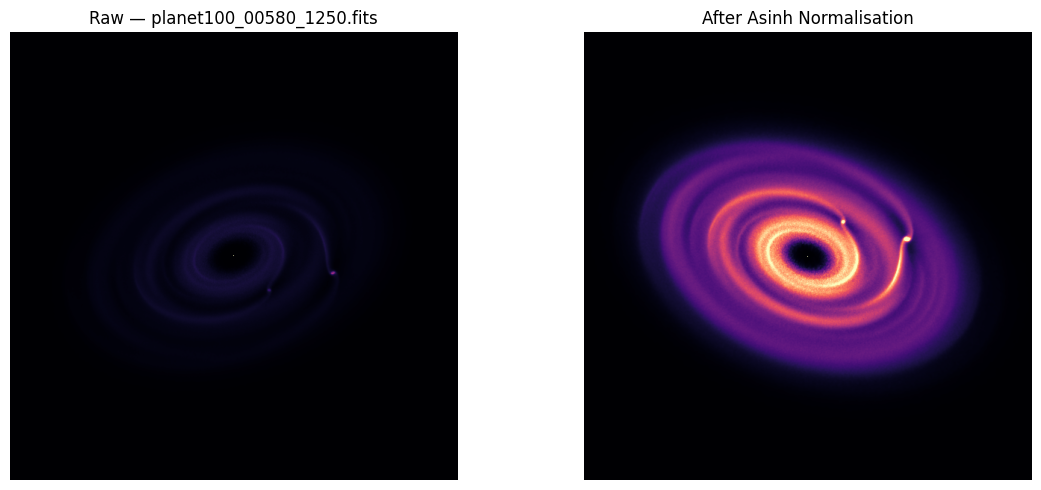

Max value       : 5.356e-21
99th percentile : 5.202e-22
50th percentile : 4.264e-24
Pixels > 0      : 81.2%


In [5]:
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".fits")])
print(f"Found {len(files)} FITS files in {DATA_DIR}")

sample_path = os.path.join(DATA_DIR, files[1])
with fits.open(sample_path) as hdul:
    raw_disk = hdul[0].data[0, 0, 0, :, :]

norm_img = asinh_stretch_normalization(raw_disk)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw_disk, cmap="magma", origin="lower")
axes[0].set_title(f"Raw — {os.path.basename(sample_path)}")
axes[1].imshow(norm_img, cmap="magma")
axes[1].set_title("After Asinh Normalisation")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Pixel statistics on the raw image
raw_clipped = np.clip(np.nan_to_num(raw_disk), 0, None)
print(f"Max value       : {raw_clipped.max():.3e}")
print(f"99th percentile : {np.percentile(raw_clipped, 99):.3e}")
print(f"50th percentile : {np.percentile(raw_clipped, 50):.3e}")
print(f"Pixels > 0      : {(raw_clipped > 0).mean()*100:.1f}%")


## 5. Dataset & DataLoaders
80 / 20 train / test split with no augmentation (augmentation is not needed for reconstruction; the model sees each disk with random orientation).

In [6]:
class FITSImageDataset(Dataset):
    """
    Loads DSHARP continuum FITS images.

    Parameters
    ----------
    root_dir : str      Folder containing .fits files.
    transform           torchvision transform applied after normalisation.
    augment  : bool     Apply random rotation + flips.
    """

    def __init__(self, root_dir, transform=None, augment=False):
        self.root_dir    = root_dir
        self.transform   = transform
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".fits")])
        print(f"Found {len(self.image_files)} FITS files in {root_dir}")
        self.aug_tf = transforms.Compose([
            transforms.RandomRotation(180),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomAffine(degrees=0, scale=(0.85, 1.15), shear=(-10, 10)),
        ]) if augment else None

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        try:
            with fits.open(img_path) as hdul:
                raw_disk = hdul[0].data[0, 0, 0, :, :]
        except Exception as e:
            print(f"Warning: could not load {img_path}: {e}")
            return torch.zeros(1, 256, 256)

        norm_img = asinh_stretch_normalization(raw_disk)
        image    = Image.fromarray((norm_img * 255).astype(np.uint8)).convert("L")

        if self.aug_tf:
            image = self.aug_tf(image)
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        return image


image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

full_dataset = FITSImageDataset(DATA_DIR, transform=image_transform, augment=False)
total_size   = len(full_dataset)
train_size   = int(TRAIN_SPLIT * total_size)
test_size    = total_size - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Total  : {total_size}  |  Train : {train_size}  |  Test : {test_size}")
print("DataLoaders created.")


Found 150 FITS files in /content/data/continuum_data_subset
Total  : 150  |  Train : 120  |  Test : 30
DataLoaders created.


## 6. Autoencoder Architecture
`(1, 256, 256)` → encoder → `(8, 64, 64)` latent → decoder → `(1, 256, 256)` reconstruction.

In [7]:
class Autoencoder(nn.Module):
    """
    Shallow CNN autoencoder for 256×256 single-channel disk images.

    Encoder : Conv(1→16) → MaxPool → Conv(16→8) → MaxPool
    Decoder : ConvTranspose(8→16) → ConvTranspose(16→1) → Sigmoid
    """

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),   # input is min-max scaled to [0, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


class CombinedLoss(nn.Module):
    """
    α · (1 − MS-SSIM) + (1 − α) · MSE

    Higher α puts more weight on structural similarity (perceptual quality).
    Lower  α puts more weight on per-pixel accuracy.
    """

    def __init__(self, alpha=0.8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.alpha = alpha

    def forward(self, pred, target):
        mse_loss     = self.mse(pred, target)
        ms_ssim_loss = 1 - ms_ssim(pred, target, data_range=1.0, size_average=True)
        return (1 - self.alpha) * mse_loss + self.alpha * ms_ssim_loss


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate a reference model to show architecture summary
_ref = Autoencoder()
print("Autoencoder architecture defined.")
print(f"Trainable parameters: {count_params(_ref):,}")
print(f"Encoder output shape (256×256 input): {_ref.encode(torch.zeros(1,1,256,256)).shape}")
del _ref


Autoencoder architecture defined.
Trainable parameters: 2,633
Encoder output shape (256×256 input): torch.Size([1, 8, 64, 64])


## 7. Training Helper

In [8]:
def train_model(criterion, save_path, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, load_pretrained=False):
    """
    Instantiate, (optionally load), train, and save an Autoencoder.

    Returns
    -------
    model : trained Autoencoder (eval mode)
    losses : list of per-epoch training losses
    """
    model     = Autoencoder().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses    = []

    if load_pretrained and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
        model.eval()
        print(f"Loaded pretrained weights from {save_path}. Skipping training.")
        return model, losses

    print(f"Training for {num_epochs} epochs  |  loss: {criterion.__class__.__name__}  |  lr: {lr}")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images in train_loader:
            images  = images.to(device)
            outputs = model(images)
            loss    = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        losses.append(epoch_loss)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {epoch_loss:.6f}")

    torch.save(model.state_dict(), save_path)
    model.eval()
    print(f"Training complete. Weights saved → {save_path}")
    return model, losses

print("train_model helper defined.")


train_model helper defined.


## 8. Model A — MSE-only Training

In [9]:
mse_model, mse_losses = train_model(
    criterion        = nn.MSELoss(),
    save_path        = MSE_MODEL_PATH,
    load_pretrained  = LOAD_MSE_PRETRAINED,
)


Training for 50 epochs  |  loss: MSELoss  |  lr: 0.001
  Epoch [  5/50]  Loss: 0.017886
  Epoch [ 10/50]  Loss: 0.009978
  Epoch [ 15/50]  Loss: 0.008349
  Epoch [ 20/50]  Loss: 0.006973
  Epoch [ 25/50]  Loss: 0.005406
  Epoch [ 30/50]  Loss: 0.003287
  Epoch [ 35/50]  Loss: 0.001812
  Epoch [ 40/50]  Loss: 0.001154
  Epoch [ 45/50]  Loss: 0.000830
  Epoch [ 50/50]  Loss: 0.000656
Training complete. Weights saved → /content/mse_only_autoencoder.pth


## 9. Model B — Combined Loss Training (MS-SSIM + MSE)

In [10]:
combined_model, combined_losses = train_model(
    criterion        = CombinedLoss(alpha=COMBINED_LOSS_ALPHA),
    save_path        = COMBINED_MODEL_PATH,
    load_pretrained  = LOAD_COMBINED_PRETRAINED,
)


Training for 50 epochs  |  loss: CombinedLoss  |  lr: 0.001
  Epoch [  5/50]  Loss: 0.193424
  Epoch [ 10/50]  Loss: 0.038514
  Epoch [ 15/50]  Loss: 0.017527
  Epoch [ 20/50]  Loss: 0.011739
  Epoch [ 25/50]  Loss: 0.009393
  Epoch [ 30/50]  Loss: 0.008146
  Epoch [ 35/50]  Loss: 0.007461
  Epoch [ 40/50]  Loss: 0.006864
  Epoch [ 45/50]  Loss: 0.006399
  Epoch [ 50/50]  Loss: 0.006033
Training complete. Weights saved → /content/combined_loss_autoencoder.pth


## 10. Training Loss Curves

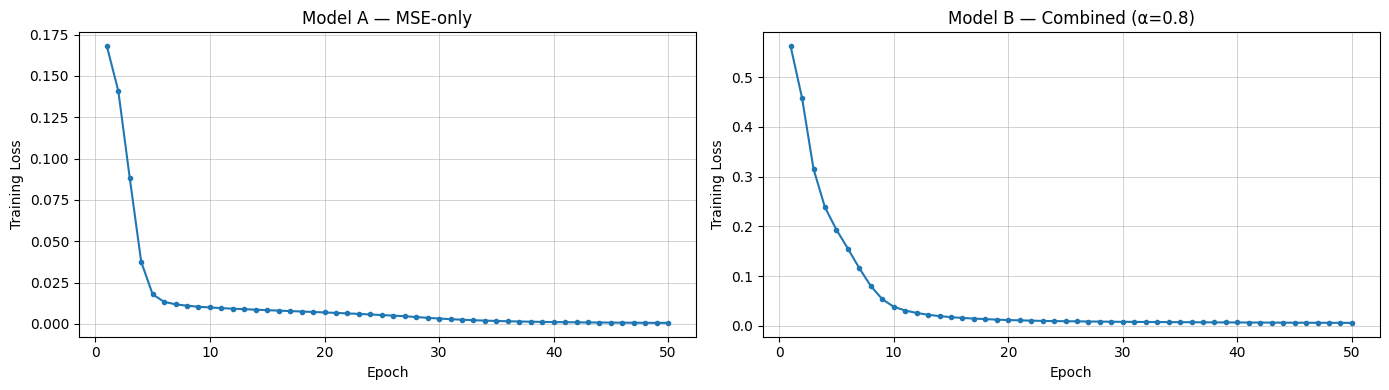

In [11]:
if mse_losses or combined_losses:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, losses, title in [
        (axes[0], mse_losses,      "Model A — MSE-only"),
        (axes[1], combined_losses, f"Model B — Combined (α={COMBINED_LOSS_ALPHA})"),
    ]:
        if losses:
            ax.plot(range(1, len(losses)+1), losses, marker="o", markersize=3)
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Training Loss")
            ax.grid(True, linewidth=0.4)
        else:
            ax.text(0.5, 0.5, "Loaded from checkpoint\n(no loss history)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("Both models loaded from checkpoints — no loss curves to plot.")


## 11. Evaluation Metrics Helper

In [16]:
def evaluate_model(model, loader):
    """
    Compute per-image MSE and MS-SSIM on a DataLoader.

    Returns
    -------
    dict with keys 'mse' and 'ms_ssim' — each a list of per-image values.
    """
    model.eval()
    scores = {"mse": [],  "ms_ssim": []}

    with torch.no_grad():
        for images in loader:
            images  = images.to(device)
            recons  = model(images)

            mse_batch    = F.mse_loss(recons, images, reduction="none").mean(dim=[1,2,3])
            ms_ssim_batch = ms_ssim(recons, images, data_range=1.0, size_average=False)

            scores["mse"].extend(mse_batch.cpu().numpy())
            scores["ms_ssim"].extend(ms_ssim_batch.cpu().numpy())


    return {k: np.array(v) for k, v in scores.items()}


def print_metrics(scores, label):
    print(f"\n{label}")
    print(f"  MSE     : {scores['mse'].mean():.6f}")
    print(f"  MS-SSIM : {scores['ms_ssim'].mean():.6f}")

print("evaluate_model and print_metrics defined.")


evaluate_model and print_metrics defined.


## 12. Quantitative Evaluation on Test Set

In [17]:
scores_mse      = evaluate_model(mse_model,      test_loader)
scores_combined = evaluate_model(combined_model,  test_loader)

print_metrics(scores_mse,      "Model A — MSE-only")
print_metrics(scores_combined,  "Model B — Combined Loss")

# Summary comparison
print("\n--- Δ (Combined − MSE-only) ---")
for metric, higher_is_better in [("mse", False),  ("ms_ssim", True)]:
    delta = scores_combined[metric].mean() - scores_mse[metric].mean()
    direction = "↑" if (delta > 0) == higher_is_better else "↓"
    print(f"  {metric.upper():8s}: {delta:+.6f}  {direction}")



Model A — MSE-only
  MSE     : 0.000613
  MS-SSIM : 0.982224

Model B — Combined Loss
  MSE     : 0.000806
  MS-SSIM : 0.994377

--- Δ (Combined − MSE-only) ---
  MSE     : +0.000192  ↓
  MS_SSIM : +0.012154  ↑


## 13. Visual Comparison — Original vs. Reconstructions
First batch of the test set shown for both models side-by-side.

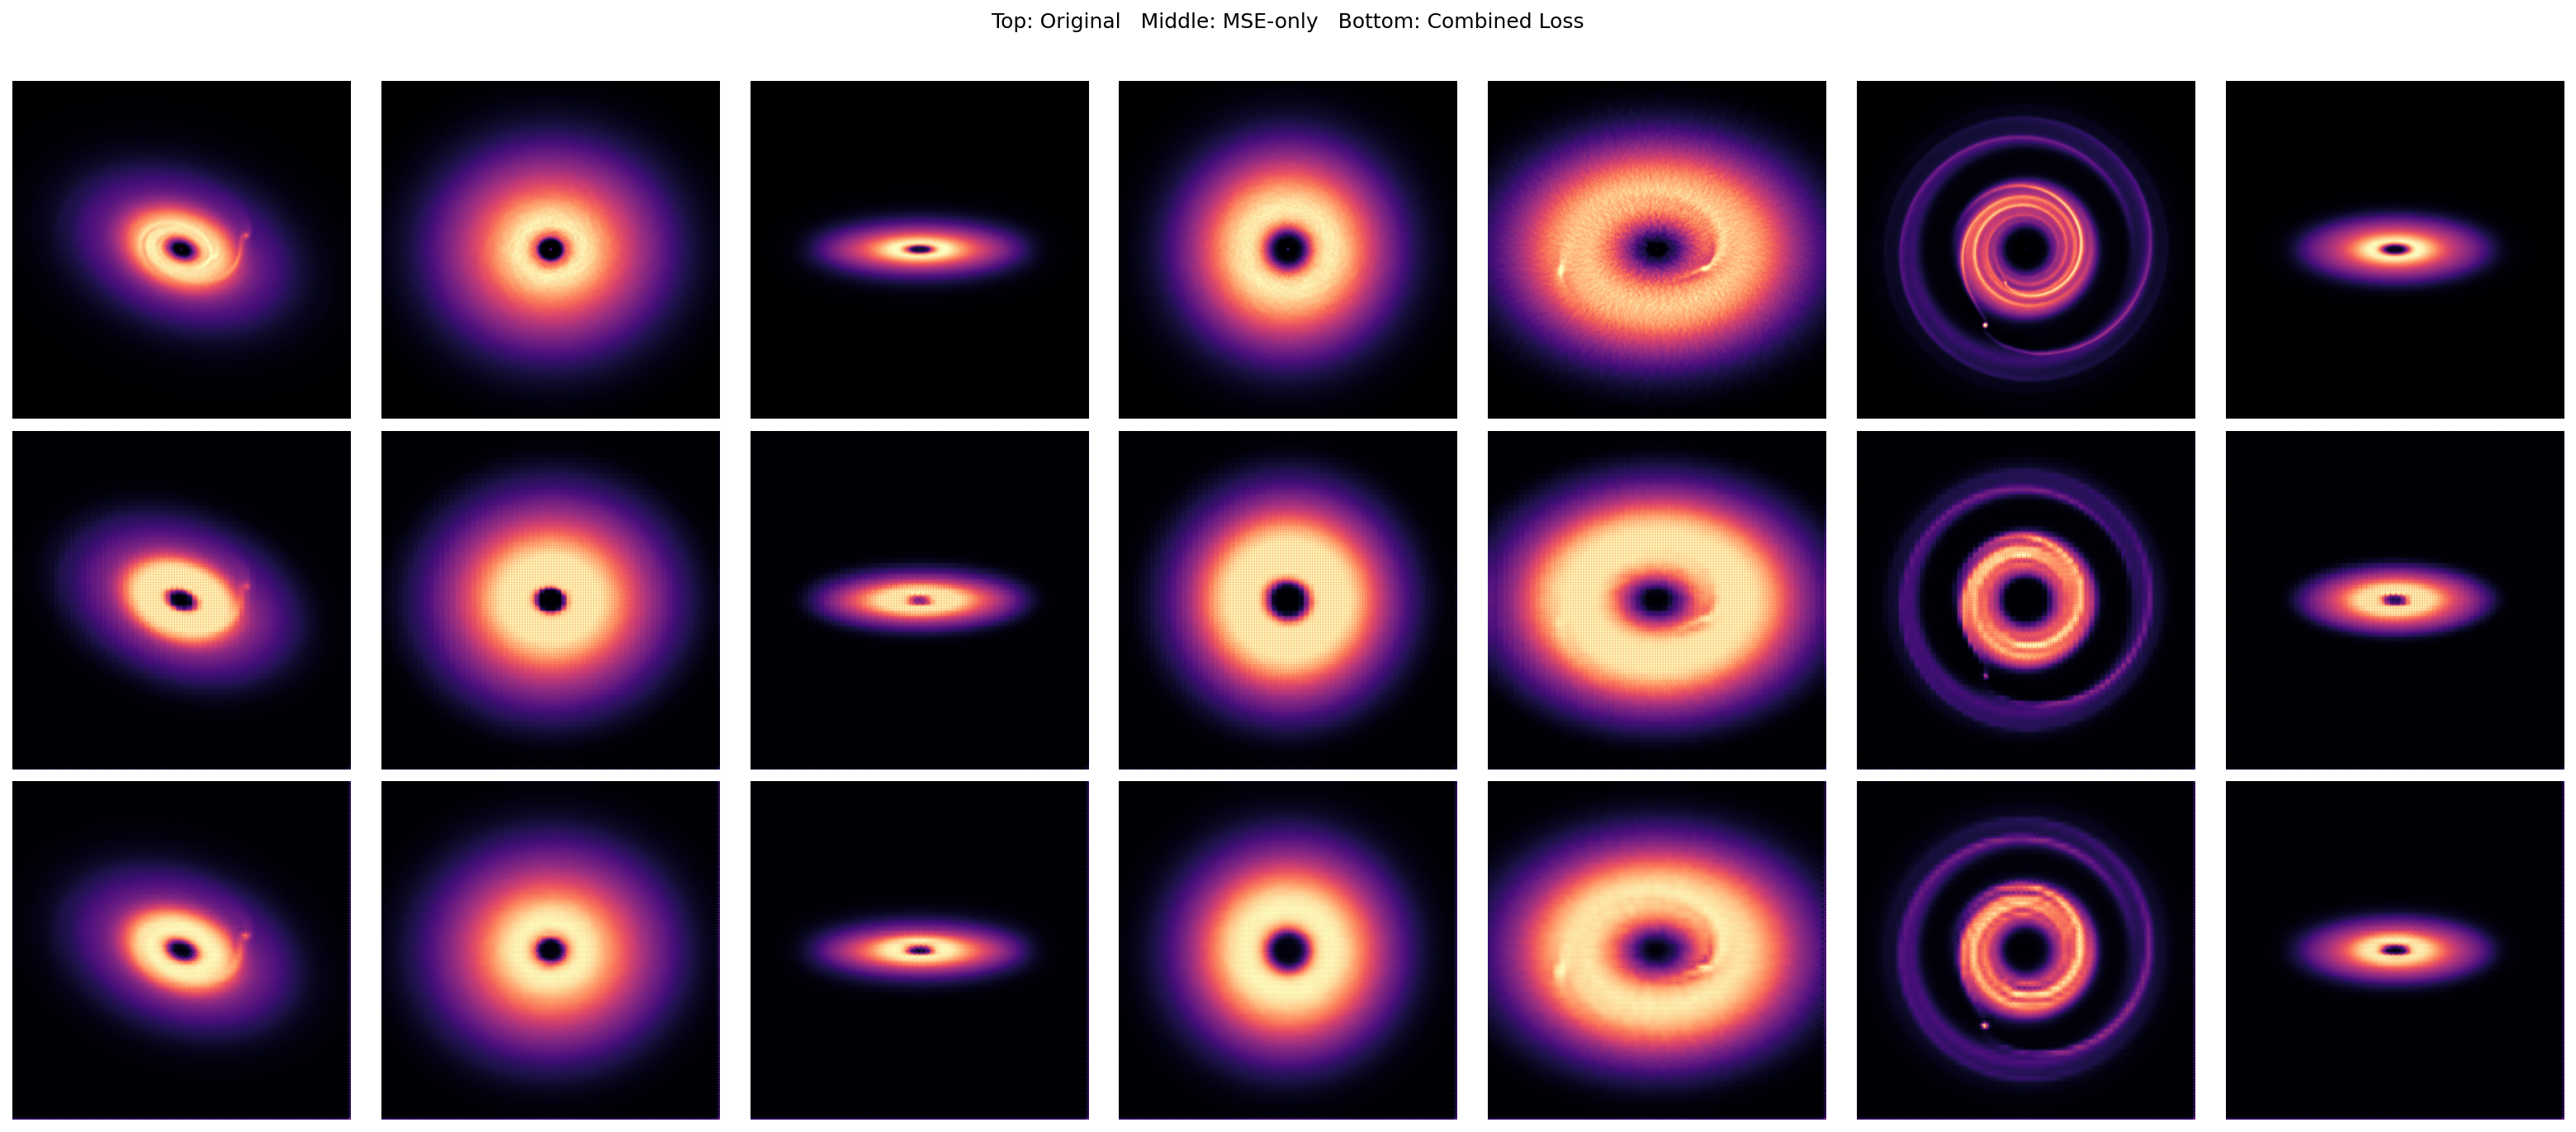

In [18]:
def show_reconstructions(model_a, model_b, loader, n=7, label_a="MSE-only", label_b="Combined"):
    """Display n test images alongside reconstructions from two models."""
    with torch.no_grad():
        batch = next(iter(loader)).to(device)
        recon_a = model_a(batch)
        recon_b = model_b(batch)

    n = min(n, batch.size(0))
    fig, axes = plt.subplots(3, n, figsize=(3*n, 9), dpi=150)
    row_labels = ["Original", label_a, label_b]
    rows = [batch, recon_a, recon_b]

    for row_idx, (row_data, row_label) in enumerate(zip(rows, row_labels)):
        for col_idx in range(n):
            img = row_data[col_idx].cpu().numpy().squeeze()
            axes[row_idx, col_idx].imshow(img, cmap="magma")
            axes[row_idx, col_idx].axis("off")
        axes[row_idx, 0].set_ylabel(row_label, fontsize=11, rotation=90, labelpad=8)

    plt.suptitle("Top: Original   Middle: MSE-only   Bottom: Combined Loss", y=1.01)
    plt.tight_layout()
    plt.show()

show_reconstructions(mse_model, combined_model, test_loader)


## 14. Latent Space Visualisation (t-SNE)
Extract encoder features from the combined-loss model and project to 2D with t-SNE. Latent space dimensionality is too high to have a meaningful representation in 2 dimensions.

Latent vector matrix shape: (30, 32768)


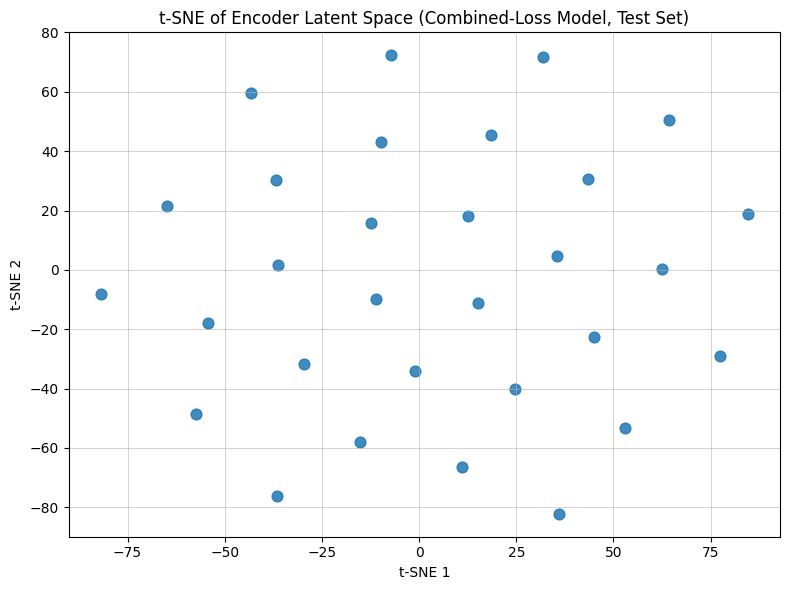

In [19]:
combined_model.eval()
latent_vectors = []

with torch.no_grad():
    for images in test_loader:
        enc = combined_model.encode(images.to(device))
        latent_vectors.append(enc.view(enc.size(0), -1).cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
print(f"Latent vector matrix shape: {latent_vectors.shape}")

if latent_vectors.shape[0] >= 5:   # t-SNE needs at least a few samples
    perplexity = min(30, latent_vectors.shape[0] - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    emb  = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(8, 6))
    plt.scatter(emb[:, 0], emb[:, 1], s=60, alpha=0.85)
    plt.title("t-SNE of Encoder Latent Space (Combined-Loss Model, Test Set)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, linewidth=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("Too few test samples for a meaningful t-SNE plot.")


---
## Inference on Withheld Data

Run both trained models on a new folder of `.fits` files **without retraining**.

**Instructions for judges:**
1. Upload your withheld `.fits` files to a folder (e.g. `/content/withheld_data`).
2. Set `INFERENCE_DATA_DIR` in the **Configuration** cell at the top.
3. Re-run this cell only.

The cell will:
- Load each image through the identical preprocessing pipeline (asinh normalisation → resize to 256×256).
- Pass through both the MSE-only and Combined-Loss models.
- Report MSE and MS-SSIM for each model.
- Display a grid of originals vs. reconstructions from both models.


In [ ]:
if INFERENCE_DATA_DIR is None:
    print("INFERENCE_DATA_DIR is not set. Skipping inference.")
    print("Set it in the Configuration cell at the top and re-run this cell.")
else:
    print(f"Running inference on: {INFERENCE_DATA_DIR}")

    infer_dataset = FITSImageDataset(INFERENCE_DATA_DIR, transform=image_transform, augment=False)
    infer_loader  = DataLoader(infer_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Loaded {len(infer_dataset)} withheld images.")

    if len(infer_dataset) == 0:
        print("No .fits files found in INFERENCE_DATA_DIR. Check the path.")
    else:
        # ── Quantitative metrics ─────────────────────────────────────────────
        infer_scores_mse      = evaluate_model(mse_model,      infer_loader)
        infer_scores_combined = evaluate_model(combined_model,  infer_loader)

        print_metrics(infer_scores_mse,      "Model A — MSE-only     (withheld data)")
        print_metrics(infer_scores_combined,  "Model B — Combined Loss (withheld data)")

        print("\n--- Δ (Combined − MSE-only) on withheld data ---")
        for metric, higher_is_better in [("mse", False), ("ssim", True), ("ms_ssim", True), ("psnr", True)]:
            delta = infer_scores_combined[metric].mean() - infer_scores_mse[metric].mean()
            direction = "↑" if (delta > 0) == higher_is_better else "↓"
            print(f"  {metric.upper():8s}: {delta:+.6f}  {direction}")

        # ── Visual comparison ────────────────────────────────────────────────
        print("\nVisualising reconstructions on withheld data...")
        show_reconstructions(mse_model, combined_model, infer_loader,
                             label_a="MSE-only", label_b="Combined Loss")

        # ── Per-image scores table ───────────────────────────────────────────
        print("\nPer-image scores (withheld data) — Combined-Loss model:")
        print(f"  {'Image':>5}  {'MSE':>10}  {'SSIM':>8}  {'MS-SSIM':>10}  {'PSNR':>8}")
        for i in range(len(infer_scores_combined["mse"])):
            fname = infer_dataset.image_files[i] if i < len(infer_dataset.image_files) else f"img_{i}"
            print(f"  {fname:>30}  "
                  f"{infer_scores_combined['mse'][i]:10.6f}  "
                  f"{infer_scores_combined['ssim'][i]:8.4f}  "
                  f"{infer_scores_combined['ms_ssim'][i]:10.4f}  "
                  f"{infer_scores_combined['psnr'][i]:8.2f} dB")

        print("\nInference complete.")
